In [1]:
import logging
import os
import sys
import yaml

import hydra
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from scipy.spatial.distance import jensenshannon
import seaborn as sns
from sklearn.metrics import r2_score
from sklearn.preprocessing import LabelEncoder
import torch
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm


In [2]:
sys.path.insert(0, "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/shared_utils")
from experiment_utils import get_forward_model, generate_with_condition

In [3]:
logger = logging.getLogger(__name__)


In [4]:
with hydra.initialize(
    config_path="../../config"
):
    config = hydra.compose(
        config_name="run_inverse_constrained",
        overrides=[
            "paths=loop2p5_replicate",
            "loss=loop2p5_replicate",
            "annotation=bloodplus",
            "constraints=default_all_cols",
        ]
    )


/tmp/ipykernel_1029091/3701908234.py:1: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with hydra.initialize(


In [5]:
scatter_cols = config.annotation.scatter_columns
protocol_cols = config.annotation.protocol_columns

In [6]:
forward_model, (
    pert_prediction_model,
    target_prediction_model
) = get_forward_model(config, logger=logger)
logger.info(f"Forward model ready!\n{forward_model}")

[2026-06-26 11:38:59] - __main__: Loading Perturbation Response Prediction Model From /lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/checkpoints/forward_model/loop2p5/2026-06-22_12-36-05/celestial-fire-40_FlowMatching.pkl...


[2026-06-26 11:40:30] - __main__: Model loaded!
NeuralVelocityField(
  (vf_modules): ModuleDict(
    (x_encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=26, out_features=256, bias=True)
          (1): ELU(alpha=1.0)
        )
        (1): Sequential(
          (0): Linear(in_features=256, out_features=256, bias=True)
          (1): ELU(alpha=1.0)
        )
        (2): Sequential(
          (0): Linear(in_features=256, out_features=1024, bias=True)
          (1): Identity()
        )
      )
    )
    (time_encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=512, out_features=256, bias=True)
          (1): ELU(alpha=1.0)
        )
        (1): Sequential(
          (0): Linear(in_features=256, out_features=256, bias=True)
          (1): ELU(alpha=1.0)
        )
        (2): Sequential(
          (0): Linear(in_features=256, out_features=256, bias=True)
          (1): Identity()
  

In [7]:
train_adata_pert = pert_prediction_model.train_data.adata
pert_channel_params = train_adata_pert.uns["X_channel_params"]
pert_scatter_params = train_adata_pert.uns["X_scatter_params"]


train_adata_target = target_prediction_model.train_data.adata
target_channel_params = train_adata_target.uns["X_channel_params"]
target_scatter_params = train_adata_target.uns["X_scatter_params"]

var_names = train_adata_target.var_names
var_names

Index(['CD49c', 'CD41a', 'CD117', 'CD38', 'HLADR', 'EPCR', 'CD135', 'CD56',
       'CD15', 'CD123', 'CD45', 'CD16', 'CD7', 'CD90', 'CD10', 'CD14',
       'CD45RA', 'CD34', 'CD235a', 'CD19'],
      dtype='object')

In [8]:
logger.info(f"Fitting label encoder on cell type...")
ct_le = LabelEncoder()
ct_values = target_prediction_model.train_data.adata.obs["cell_type"].values
ct_le.fit(ct_values)
classes = ct_le.classes_
classes

[2026-06-26 11:40:33] - __main__: Fitting label encoder on cell type...


array(['CD14Mono', 'CD16Mono', 'CyclingPro1', 'CyclingPro2', 'Early_GMP',
       'EosBasMast1', 'EosBasMast2', 'EosBasMast3', 'EryPro',
       'GMP-Neutro', 'GMP_cycling', 'HSCs', 'LMPP-CLP', 'MLP', 'MPP',
       'MPP_MgkEry', 'MgKEryPro1', 'MgKEryPro2', 'ProB', 'earlyMPP',
       'late_MgkPro', 'preProB', 'pre_cDC1', 'pre_cDC2'], dtype=object)

In [9]:
loop2p5_h5ad_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop2p5/replicate/adata_500k.h5ad"
adata_loop2p5 = sc.read_h5ad(loop2p5_h5ad_path)
adata_loop2p5

AnnData object with n_obs × n_vars = 1499951 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'meta', 'processing_steps'
    layers: 'positives', 'raw'

In [10]:
X_channel = adata_loop2p5.X
X_scatter = adata_loop2p5.obs[scatter_cols].astype(float).values
X = np.concatenate((X_channel, X_scatter), axis=1)


X_channel_transf_pert = (X_channel - pert_channel_params["mean"])/pert_channel_params["std"]
X_scatter_transf_pert = (X_scatter - pert_scatter_params["mean"])/pert_scatter_params["std"]
X_transf_pert = np.concatenate((X_channel_transf_pert, X_scatter_transf_pert), axis=1)


X_channel_transf_target = (X_channel - target_channel_params["mean"])/target_channel_params["std"]
X_scatter_transf_target = (X_scatter - target_scatter_params["mean"])/target_scatter_params["std"]
X_transf_target = np.concatenate((X_channel_transf_target, X_scatter_transf_target), axis=1)


In [11]:
X_torch_target = torch.from_numpy(X_transf_target).to(torch.float32).to(target_prediction_model.device)
dataset = TensorDataset(X_torch_target)
dataloader = DataLoader(dataset, batch_size=10_000, shuffle=False)


In [12]:
# ---- List to store the predictions ----
ct_probs = []
ct_preds = []

# ---- Classify cell types ---
with torch.no_grad():
    for xb in tqdm(dataloader):
        xb = xb[0]
        y_logits = target_prediction_model.predict(xb)["cell_type_reannot_final"]

        y_prob = torch.nn.functional.softmax(y_logits, dim=1)
        y_pred = y_prob.argmax(1)

        ct_probs.append(y_prob.cpu().detach().numpy())
        ct_preds.append(y_pred.cpu().detach().numpy())

ct_probs_real = np.concatenate(ct_probs)
ct_preds_real = np.concatenate(ct_preds)

# ---- Decode predicted cell types ----
ct_preds_real = classes[ct_preds_real]

# ---- Write back to anndata ----
adata_loop2p5.obs["cell_type"] = ct_preds_real
adata_loop2p5

100%|██████████| 150/150 [00:10<00:00, 14.15it/s]


AnnData object with n_obs × n_vars = 1499951 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'cell_type'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'meta', 'processing_steps'
    layers: 'positives', 'raw'

In [13]:
protocol_data = adata_loop2p5.obs[protocol_cols].astype(float).values
unique_protocols = np.unique(protocol_data, axis=0)
print(unique_protocols.shape[0])

protocol_data_log1p = np.log1p(protocol_data)
unique_protocols_log1p = np.log1p(unique_protocols)


115


In [14]:
all_records_real = []

for cond_idx, cond in enumerate(unique_protocols):
    cond_mask = np.all(protocol_data == cond, axis=1)
    n_obs = cond_mask.sum()

    ct_probs = ct_probs_real[cond_mask]
    x_channel = X_channel_transf_pert[cond_mask]
    x_scatter = X_scatter_transf_pert[cond_mask]

    mean_ct_probs = ct_probs.mean(0) # N, C -> C
    mean_channel_gen = x_channel.mean(0) # N, D_c -> D_c
    mean_scatter_gen = x_scatter.mean(0) # N, D_s -> D_s

    std_ct_probs = ct_probs.std(0) # N, C -> C
    std_channel_gen = x_channel.std(0) # N, D_c -> D_c
    std_scatter_gen = x_scatter.std(0) # N, D_s -> D_s

    record_dict = {
        **{f"{classes[idx]}:mean": x for idx, x in enumerate(mean_ct_probs)},
        **{f"{var_names[idx]}:mean": x for idx, x in enumerate(mean_channel_gen)},
        **{f"{scatter_cols[idx]}:mean": x for idx, x in enumerate(mean_scatter_gen)},
        **{f"{classes[idx]}:std": x for idx, x in enumerate(std_ct_probs)},
        **{f"{var_names[idx]}:std": x for idx, x in enumerate(std_channel_gen)},
        **{f"{scatter_cols[idx]}:std": x for idx, x in enumerate(std_scatter_gen)},
    }
    all_records_real.append(record_dict)

real_stats_df = pd.DataFrame(all_records_real)
real_stats_df

,CD14Mono:mean,CD16Mono:mean,CyclingPro1:mean,CyclingPro2:mean,Early_GMP:mean,EosBasMast1:mean,EosBasMast2:mean,EosBasMast3:mean,EryPro:mean,GMP-Neutro:mean,...,CD45RA:std,CD34:std,CD235a:std,CD19:std,FSC-A :: FSC - Area:std,FSC-H :: FSC - Height:std,FSC-W :: FSC - Width:std,SSC-A :: SSC - Area:std,SSC-H :: SSC - Height:std,SSC-W :: SSC - Width:std
0,0.001515,0.000024,0.000309,0.000032,0.042745,0.014236,0.000465,0.020202,0.000255,0.027884,...,0.890020,1.472982,0.770952,1.405369,0.685006,0.751859,0.709249,0.496156,0.506981,0.777465
1,0.000282,0.000046,0.000251,0.000271,0.131015,0.053664,0.002935,0.004242,0.000106,0.223527,...,0.687898,0.779657,0.475306,0.840821,0.651444,0.731514,0.771269,0.468564,0.509356,0.733063
2,0.000118,0.000028,0.000489,0.000036,0.087963,0.002037,0.001077,0.008947,0.000406,0.159121,...,0.685616,1.144142,0.621626,2.157079,0.643220,0.713814,0.729601,0.484358,0.488118,0.800752
3,0.001086,0.022347,0.000049,0.000436,0.060489,0.086366,0.001416,0.000414,0.058816,0.082028,...,0.844904,0.888435,1.205503,1.387653,1.266953,1.236943,1.379043,1.275469,1.206697,1.222055
4,0.001338,0.000103,0.000005,0.000012,0.031736,0.065336,0.001783,0.000011,0.024185,0.031542,...,0.702421,0.706477,0.686474,0.809876,1.215695,1.168533,1.357997,1.215784,1.194492,1.245645
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110,0.000013,0.000213,0.544816,0.000402,0.000613,0.000041,0.101209,0.000284,0.001181,0.204603,...,0.038385,0.446374,0.792680,1.055784,0.888528,0.871386,0.970684,1.037609,1.034914,0.914383
111,0.000013,0.001278,0.641748,0.004543,0.000103,0.000184,0.084563,0.001435,0.000220,0.172402,...,0.040138,0.356907,0.888435,1.178391,1.195956,1.063010,1.164948,2.002997,1.874158,1.078792
112,0.003577,0.024125,0.000094,0.000012,0.064651,0.125247,0.001203,0.000316,0.003143,0.385436,...,0.815442,0.667070,0.494664,0.837441,0.715270,0.789768,0.889417,0.700890,0.729503,0.887622
113,0.000076,0.042945,0.378247,0.001890,0.000033,0.000065,0.053500,0.000349,0.000254,0.153236,...,0.049314,0.325739,0.552850,0.881302,0.870626,0.969732,1.041910,0.846765,0.879533,1.160193


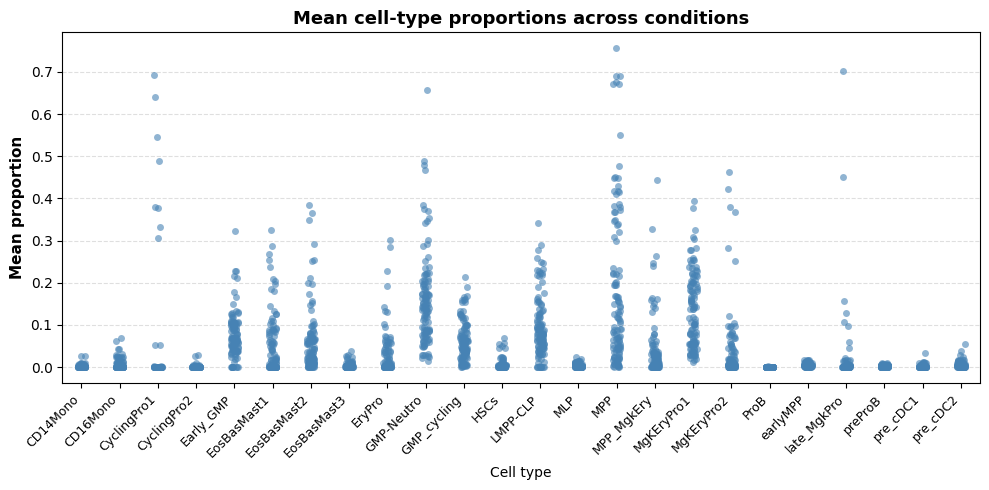

In [15]:
# Extract mean proportion columns (same as before)
ct_cols = [c for c in real_stats_df.columns
           if c.endswith(':mean') and c.replace(':mean', '') in classes]

# Build a long-format DataFrame for seaborn
long_ct = real_stats_df[ct_cols].copy()
long_ct.columns = [c.replace(':mean', '') for c in ct_cols]   # strip suffix
long_ct = long_ct.melt(var_name='Cell type', value_name='Mean proportion')

# ----- Stripplot -----
plt.figure(figsize=(10, 5))
sns.stripplot(
    data=long_ct,
    x='Cell type',
    y='Mean proportion',
    color='steelblue',
    alpha=0.6,
    size=5,
    jitter=True          # spreads points horizontally to avoid overlap
)

# Optionally overlay a boxplot for context
# sns.boxplot(data=long_ct, x='Cell type', y='Mean proportion',
#             width=0.4, boxprops={'alpha':0.3}, fliersize=0)

plt.xticks(rotation=45, ha='right', fontsize=9)
plt.ylabel('Mean proportion', fontsize=11, fontweight='bold')
plt.title('Mean cell‑type proportions across conditions', fontsize=13, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [16]:
n_samples = 10_000
n_time_steps = 100
solver_kwargs = {"method":  "euler", "atol": 5e-5, "rtol": 5e-5}

samples_dict = {}
for cond_idx, x_cond in tqdm(enumerate(unique_protocols_log1p)):
    fwd_query_res_dict = generate_with_condition(
        x_cond[None],
        forward_model,
        n_time_steps,
        solver_kwargs,
        ct_le,
        num_samples=n_samples,
        logger=logger,
        cell_type_column="cell_type_reannot_final"
    )
    samples_dict[cond_idx] = fwd_query_res_dict


0it [00:00, ?it/s]

[2026-06-26 11:41:02] - __main__: X_gen.shape=(10000, 1, 26), X_channel_gen.shape=(10000, 1, 20), X_scatter_gen.shape=(10000, 1, 6), gen_ct_logits.shape=(10000, 1, 24)


1it [00:01,  1.67s/it]

[2026-06-26 11:41:02] - __main__: X_gen.shape=(10000, 1, 26), X_channel_gen.shape=(10000, 1, 20), X_scatter_gen.shape=(10000, 1, 6), gen_ct_logits.shape=(10000, 1, 24)


2it [00:02,  1.20s/it]

...

113it [01:37,  1.18it/s]

[2026-06-26 11:42:38] - __main__: X_gen.shape=(10000, 1, 26), X_channel_gen.shape=(10000, 1, 20), X_scatter_gen.shape=(10000, 1, 6), gen_ct_logits.shape=(10000, 1, 24)


114it [01:38,  1.18it/s]

[2026-06-26 11:42:39] - __main__: X_gen.shape=(10000, 1, 26), X_channel_gen.shape=(10000, 1, 20), X_scatter_gen.shape=(10000, 1, 6), gen_ct_logits.shape=(10000, 1, 24)


115it [01:39,  1.16it/s]


In [17]:
all_records_gen = []
for cond_idx, cond_pred in samples_dict.items():
    ct_probs_gen = cond_pred["ct_probs"] # N, 1, C
    x_channel_gen = cond_pred["X_channel"] # N, 1, D_c
    x_scatter_gen = cond_pred["X_scatter"] # N, 1, D_s

    mean_ct_probs = ct_probs_gen.mean(0)[0] # N, 1, C -> 1, C -> C
    mean_channel_gen = x_channel_gen.mean(0)[0] # N, 1, D_c -> 1, D_c -> D_c
    mean_scatter_gen = x_scatter_gen.mean(0)[0] # N, 1, D_s -> 1, D_s -> D_s

    std_ct_probs = ct_probs_gen.std(0)[0] # N, 1, C -> 1, C -> C
    std_channel_gen = x_channel_gen.std(0)[0] # N, 1, D_c -> 1, D_c -> D_c
    std_scatter_gen = x_scatter_gen.std(0)[0] # N, 1, D_s -> 1, D_s -> D_s

    record_dict = {
        **{f"{classes[idx]}:mean": x for idx, x in enumerate(mean_ct_probs)},
        **{f"{var_names[idx]}:mean": x for idx, x in enumerate(mean_channel_gen)},
        **{f"{scatter_cols[idx]}:mean": x for idx, x in enumerate(mean_scatter_gen)},
        **{f"{classes[idx]}:std": x for idx, x in enumerate(std_ct_probs)},
        **{f"{var_names[idx]}:std": x for idx, x in enumerate(std_channel_gen)},
        **{f"{scatter_cols[idx]}:std": x for idx, x in enumerate(std_scatter_gen)},
    }
    all_records_gen.append(record_dict)

gen_stats_df = pd.DataFrame(all_records_gen)
gen_stats_df

,CD14Mono:mean,CD16Mono:mean,CyclingPro1:mean,CyclingPro2:mean,Early_GMP:mean,EosBasMast1:mean,EosBasMast2:mean,EosBasMast3:mean,EryPro:mean,GMP-Neutro:mean,...,CD45RA:std,CD34:std,CD235a:std,CD19:std,FSC-A :: FSC - Area:std,FSC-H :: FSC - Height:std,FSC-W :: FSC - Width:std,SSC-A :: SSC - Area:std,SSC-H :: SSC - Height:std,SSC-W :: SSC - Width:std
0,0.003305,0.000910,0.000920,0.000198,0.078823,0.031624,0.006431,0.005776,0.013637,0.061084,...,1.061828,1.460495,0.874957,1.168822,0.829826,0.873890,0.841538,0.815362,0.827277,0.969918
1,0.003402,0.001047,0.002908,0.000176,0.095883,0.031979,0.010568,0.004831,0.014229,0.097672,...,0.993127,1.364819,0.816306,1.128308,0.841839,0.880644,0.859385,0.820492,0.824645,0.977385
2,0.003482,0.004136,0.011949,0.000531,0.088909,0.027115,0.031087,0.002160,0.028617,0.256944,...,0.733884,0.906556,0.724984,0.992679,0.869868,0.899748,0.919039,0.891712,0.915919,0.980884
3,0.001149,0.002196,0.000817,0.000470,0.109082,0.068302,0.008780,0.000668,0.026644,0.144641,...,0.846000,0.731123,0.775476,0.881395,1.031865,1.026431,1.094832,0.998397,0.973629,1.117958
4,0.000703,0.001179,0.000579,0.000240,0.039172,0.051372,0.002043,0.000245,0.012587,0.038221,...,0.667188,0.610299,0.732775,0.933139,1.164094,1.125937,1.214169,1.173301,1.147884,1.181884
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110,0.002460,0.008929,0.525668,0.000324,0.005964,0.009096,0.048758,0.000329,0.004169,0.174934,...,0.306855,0.620182,0.703988,0.944911,0.966059,0.923089,0.996168,1.232423,1.241082,1.000438
111,0.001106,0.011292,0.786980,0.000171,0.000552,0.002936,0.032739,0.000520,0.001538,0.089325,...,0.153700,0.400491,0.703755,1.004799,0.996679,0.950557,1.039866,1.277536,1.258522,1.044121
112,0.002857,0.002440,0.001112,0.000819,0.111566,0.020414,0.038957,0.001353,0.025894,0.163072,...,1.164340,1.044522,0.924884,0.997119,0.930329,0.928940,0.910152,0.901939,0.895021,1.013335
113,0.005731,0.050552,0.298470,0.001709,0.009872,0.014152,0.047096,0.000884,0.019497,0.138198,...,0.316838,0.376561,0.913265,0.902077,0.875041,0.947262,1.076703,0.918935,0.912759,1.092002


/tmp/ipykernel_1029091/1601415025.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


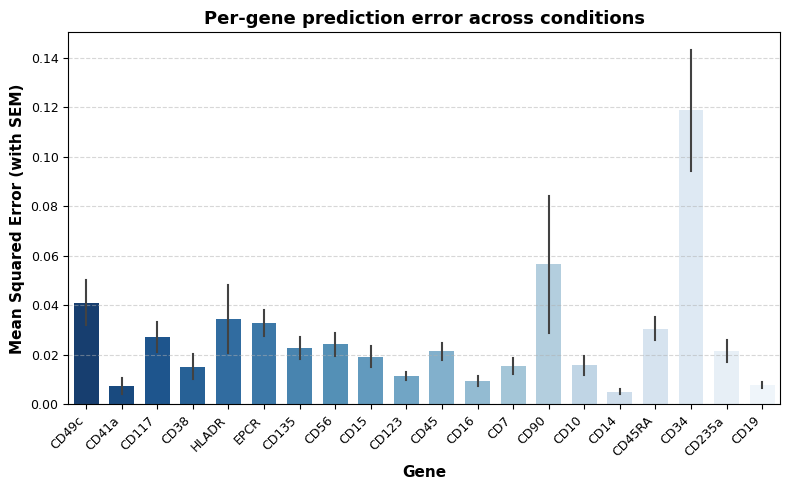

In [18]:
# 1. Select only columns for var_names
var_mean_cols = [c for c in real_stats_df.columns
                 if c.endswith(':mean') and c.replace(':mean', '') in var_names]

# 2. Compute per-condition squared error for each gene
#    real_stats_df and gen_stats_df have shape (n_conditions, n_features)
real_var_means = real_stats_df[var_mean_cols].values   # (n_cond, n_genes)
gen_var_means  = gen_stats_df[var_mean_cols].values

sq_errors = (real_var_means - gen_var_means) ** 2      # (n_cond, n_genes)

# 3. Build a long-format DataFrame for seaborn
gene_names = [c.replace(':mean', '') for c in var_mean_cols]

records = []
for i, gene in enumerate(gene_names):
    for cond_idx in range(sq_errors.shape[0]):
        records.append({'gene': gene, 'condition': cond_idx,
                        'squared_error': sq_errors[cond_idx, i]})

long_df = pd.DataFrame(records)

# 4. Plot with error bars (SEM) and customized style
plt.figure(figsize=(8, 5))                # smaller figure

# Use seaborn barplot, which shows mean and error bars automatically
sns.barplot(
    data=long_df,
    x='gene',
    y='squared_error',
    estimator='mean',
    errorbar='se',               # standard error of the mean
    err_kws={'linewidth': 1.5},  # thicker error bar caps
    palette='Blues_r',           # optional: reversed Blues for darker=higher
    width=0.7                    # slightly thicker bars
)

# Styling
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.xlabel('Gene', fontsize=11, fontweight='bold')
plt.ylabel('Mean Squared Error (with SEM)', fontsize=11, fontweight='bold')
plt.title('Per‑gene prediction error across conditions', fontsize=13, fontweight='bold')

# Add a light grid for readability
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

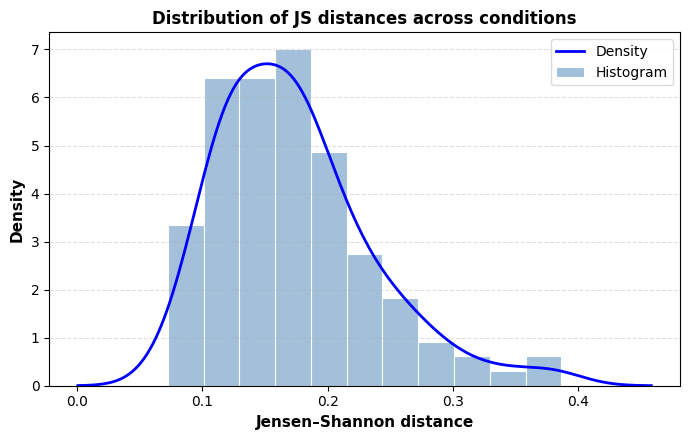

Mean JS distance  : 0.1735
Median JS distance: 0.1681
Min / Max         : 0.0724 / 0.3864


In [19]:
# ---------- Extract cell-type proportion columns ----------
ct_cols = [c for c in real_stats_df.columns
           if c.endswith(':mean') and c.replace(':mean', '') in classes]

real_props = real_stats_df[ct_cols].values
gen_props  = gen_stats_df[ct_cols].values

# Normalise each row to sum to 1
real_props = real_props / real_props.sum(axis=1, keepdims=True)
gen_props  = gen_props / gen_props.sum(axis=1, keepdims=True)

# ---------- Jensen–Shannon distance per condition ----------
js_distances = np.array([
    jensenshannon(real_props[i], gen_props[i]) for i in range(real_props.shape[0])
])

# ---------- Histogram + density plot ----------
plt.figure(figsize=(7, 4.5))
sns.histplot(
    js_distances,
    bins='auto',               # or fix number, e.g., bins=20
    stat='density',
    color='steelblue',
    alpha=0.5,
    edgecolor='white',
    linewidth=0.8,
    label='Histogram'
)
sns.kdeplot(
    js_distances,
    color='blue',
    linewidth=2,
    label='Density'
)

plt.xlabel('Jensen–Shannon distance', fontsize=11, fontweight='bold')
plt.ylabel('Density', fontsize=11, fontweight='bold')
plt.title('Distribution of JS distances across conditions', fontsize=12, fontweight='bold')
plt.legend(frameon=True, facecolor='white', edgecolor='lightgrey')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Print summary
print(f"Mean JS distance  : {js_distances.mean():.4f}")
print(f"Median JS distance: {np.median(js_distances):.4f}")
print(f"Min / Max         : {js_distances.min():.4f} / {js_distances.max():.4f}")


Overall R²  : 0.8317
Pearson r   : 0.9156


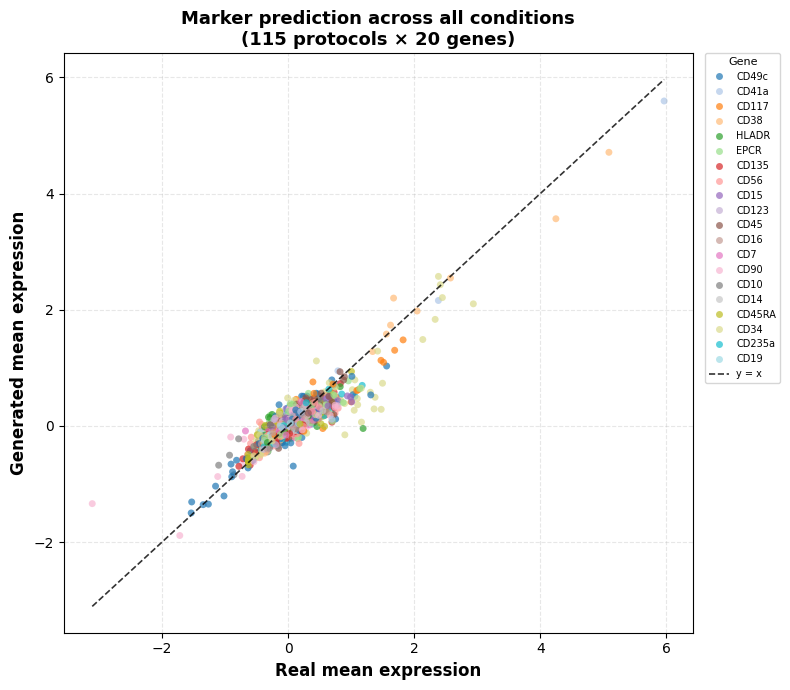

In [20]:
# ---------- 1. Extract marker mean columns ----------
var_mean_cols = [c for c in real_stats_df.columns
                 if c.endswith(':mean') and c.replace(':mean', '') in var_names]

real_vals = real_stats_df[var_mean_cols].values   # shape (n_cond, n_genes)
gen_vals  = gen_stats_df[var_mean_cols].values

n_cond, n_genes = real_vals.shape
gene_names = [c.replace(':mean', '') for c in var_mean_cols]

# ---------- 2. Flatten into long format ----------
flat_real = real_vals.ravel()          # length n_cond*n_genes
flat_gen  = gen_vals.ravel()

# Create a DataFrame with condition and gene labels
long_df = pd.DataFrame({
    'Real':      flat_real,
    'Generated': flat_gen,
    'Gene':      np.tile(gene_names, n_cond),
    'Condition': np.repeat(np.arange(n_cond), n_genes)
})

# ---------- 3. Plot ----------
plt.figure(figsize=(8, 7))

# Scatter all points, colored by gene
sns.scatterplot(
    data=long_df,
    x='Real',
    y='Generated',
    hue='Gene',
    palette='tab20',          # up to 20 distinct colors
    alpha=0.7,
    edgecolor='none',
    s=25                      # dot size
)

# Diagonal line y = x
lims = [
    min(long_df['Real'].min(), long_df['Generated'].min()),
    max(long_df['Real'].max(), long_df['Generated'].max())
]
plt.plot(lims, lims, 'k--', linewidth=1.2, alpha=0.8, label='y = x')

# Styling
plt.xlabel('Real mean expression', fontsize=12, fontweight='bold')
plt.ylabel('Generated mean expression', fontsize=12, fontweight='bold')
plt.title(f'Marker prediction across all conditions\n({n_cond} protocols × {n_genes} genes)',
          fontsize=13, fontweight='bold')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0,
           fontsize=7, title='Gene', title_fontsize=8)
plt.grid(linestyle='--', alpha=0.3)
plt.tight_layout()

# ---------- 4. Print global metrics ----------
r2 = r2_score(flat_real, flat_gen)
corr = np.corrcoef(flat_real, flat_gen)[0, 1]
print(f"Overall R²  : {r2:.4f}")
print(f"Pearson r   : {corr:.4f}")

plt.show()

Marker std overall R² : 0.6291
Marker std Pearson r  : 0.8021


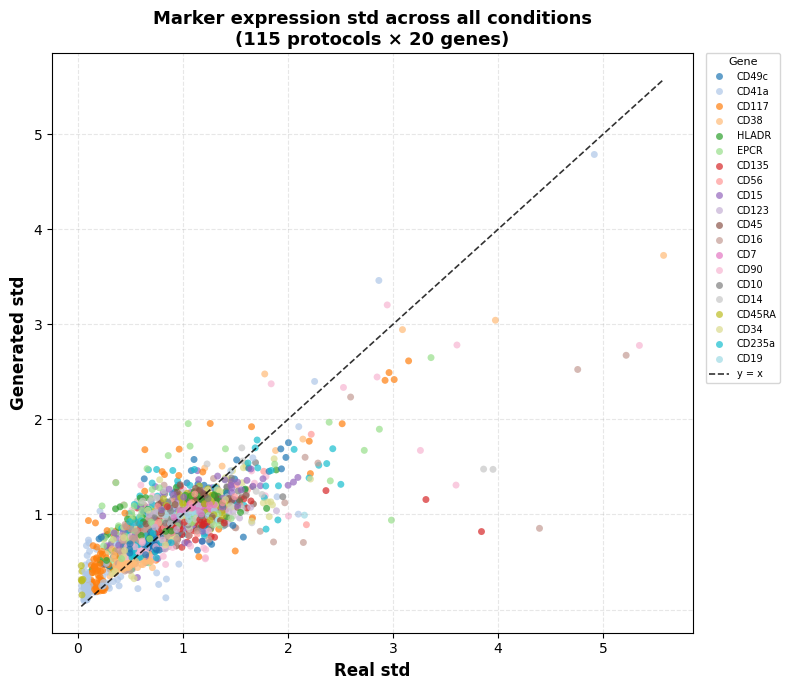

In [21]:
# ---------- 1. Extract std columns for markers ----------
var_std_cols = [c for c in real_stats_df.columns
                if c.endswith(':std') and c.replace(':std', '') in var_names]

real_std_vals = real_stats_df[var_std_cols].values   # shape (n_cond, n_genes)
gen_std_vals  = gen_stats_df[var_std_cols].values

n_cond, n_genes = real_std_vals.shape
gene_names = [c.replace(':std', '') for c in var_std_cols]

# ---------- 2. Flatten ----------
flat_real_std = real_std_vals.ravel()
flat_gen_std  = gen_std_vals.ravel()

marker_std_long = pd.DataFrame({
    'Real':      flat_real_std,
    'Generated': flat_gen_std,
    'Gene':      np.tile(gene_names, n_cond),
    'Condition': np.repeat(np.arange(n_cond), n_genes)
})

# ---------- 3. Scatter plot ----------
plt.figure(figsize=(8, 7))
sns.scatterplot(
    data=marker_std_long,
    x='Real',
    y='Generated',
    hue='Gene',
    palette='tab20',
    alpha=0.7,
    edgecolor='none',
    s=25
)

lims = [
    min(marker_std_long['Real'].min(), marker_std_long['Generated'].min()),
    max(marker_std_long['Real'].max(), marker_std_long['Generated'].max())
]
plt.plot(lims, lims, 'k--', linewidth=1.2, alpha=0.8, label='y = x')

plt.xlabel('Real std', fontsize=12, fontweight='bold')
plt.ylabel('Generated std', fontsize=12, fontweight='bold')
plt.title(f'Marker expression std across all conditions\n({n_cond} protocols × {n_genes} genes)',
          fontsize=13, fontweight='bold')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0,
           fontsize=7, title='Gene', title_fontsize=8)
plt.grid(linestyle='--', alpha=0.3)
plt.tight_layout()

# ---------- 4. Metrics ----------
r2_std_markers = r2_score(flat_real_std, flat_gen_std)
corr_std_markers = np.corrcoef(flat_real_std, flat_gen_std)[0, 1]
print(f"Marker std overall R² : {r2_std_markers:.4f}")
print(f"Marker std Pearson r  : {corr_std_markers:.4f}")
plt.show()

Overall R²  : 0.8531
Pearson r   : 0.9246


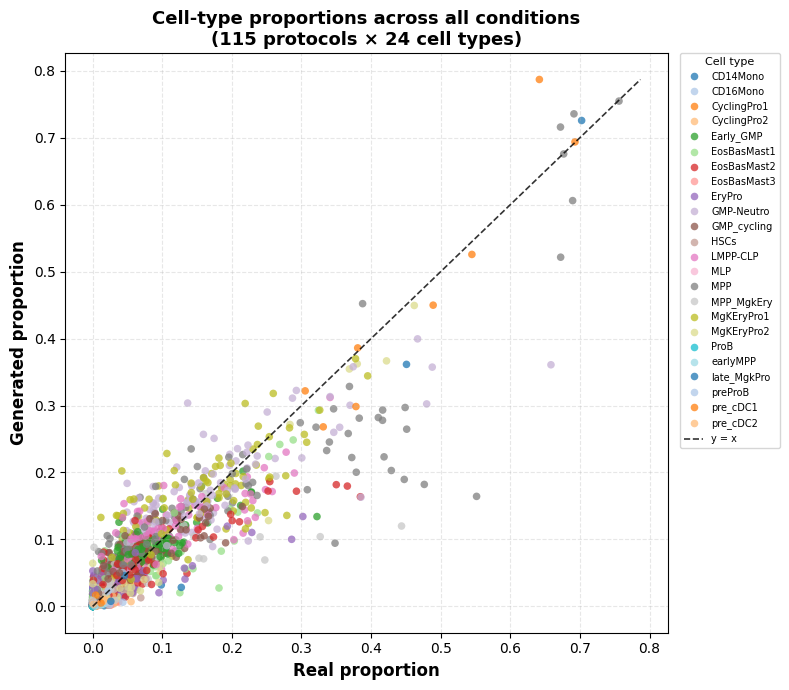

In [22]:
# ---------- 1. Extract cell-type proportion columns ----------
ct_cols = [c for c in real_stats_df.columns
           if c.endswith(':mean') and c.replace(':mean', '') in classes]

real_props = real_stats_df[ct_cols].values   # shape (n_cond, n_celltypes)
gen_props  = gen_stats_df[ct_cols].values

# Normalise each row to sum to 1 (in case of numerical drift)
real_props = real_props / real_props.sum(axis=1, keepdims=True)
gen_props  = gen_props / gen_props.sum(axis=1, keepdims=True)

n_cond, n_ct = real_props.shape
ct_names = classes   # from LabelEncoder

# ---------- 2. Flatten ----------
flat_real = real_props.ravel()
flat_gen  = gen_props.ravel()

ct_long = pd.DataFrame({
    'Real':      flat_real,
    'Generated': flat_gen,
    'Cell type': np.tile(ct_names, n_cond),
    'Condition': np.repeat(np.arange(n_cond), n_ct)
})

# ---------- 3. Scatter plot ----------
plt.figure(figsize=(8, 7))
sns.scatterplot(
    data=ct_long,
    x='Real',
    y='Generated',
    hue='Cell type',
    palette='tab20',   # adequate if ≤20 cell types
    alpha=0.75,
    edgecolor='none',
    s=30
)

# Diagonal line
lims = [
    min(ct_long['Real'].min(), ct_long['Generated'].min()),
    max(ct_long['Real'].max(), ct_long['Generated'].max())
]
plt.plot(lims, lims, 'k--', linewidth=1.2, alpha=0.8, label='y = x')

# Styling
plt.xlabel('Real proportion', fontsize=12, fontweight='bold')
plt.ylabel('Generated proportion', fontsize=12, fontweight='bold')
plt.title(f'Cell‑type proportions across all conditions\n({n_cond} protocols × {n_ct} cell types)',
          fontsize=13, fontweight='bold')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0,
           fontsize=7, title='Cell type', title_fontsize=8)
plt.grid(linestyle='--', alpha=0.3)
plt.tight_layout()

# ---------- 4. Summary metrics ----------
r2 = r2_score(flat_real, flat_gen)
corr = np.corrcoef(flat_real, flat_gen)[0, 1]
print(f"Overall R²  : {r2:.4f}")
print(f"Pearson r   : {corr:.4f}")

plt.show()